# Notebook 4: Linear Probe — Predict Foreground Despite Different Background

## Goal
We create **many contradictory composite images**: we paste the **object (foreground)** from one image on top of a **different full image (background)**. The **correct label is always the foreground object** (the one in the middle), no matter what background we put behind it. We want the model to **still predict correctly** even when the background is different.

## How we train
1. **Data:** For many image pairs (A, B), we build two composites: (A's object on full B) and (B's object on full A). So we get lots of "combined contradictory" images where the foreground is one object and the background is another scene.
2. **Label:** For each composite, the **correct label** = the image that donated the **foreground** (the object in the middle). So we want the model to say "this composite is more like A" when A's object is pasted on, and "more like B" when B's object is pasted on.
3. **CLIP (frozen):** We run CLIP on the composite and on A and B, and get two similarities: sim(composite, A) and sim(composite, B).
4. **Probe:** We train a **small linear head** on these two numbers to predict the correct label (foreground = A or B). So we use **all our contradictory composites** to teach the probe to pick the foreground donor from (sim_A, sim_B).
5. **Result:** We compare accuracy **before** (zero-shot: pick whichever of A/B has higher similarity) vs **after** (probe trained on all data).

**Why the probe can be better:** Zero-shot only uses the two numbers (sim_A, sim_B) and picks the larger. The probe gets **the full composite embedding plus those two numbers** (514-d input). So it can learn to correct when the two similarities are close or misleading — e.g. when the composite embedding has cues about which image donated the foreground that raw similarity misses. We use a small MLP (514 -> 128 -> 2) to learn this better boundary.

**Run order:** Run cells from top. Section 4 collects data; Section 5 trains on **all data**; Section 6 evaluates and plots.

## 1. Setup and Imports

In [16]:
import random
from pathlib import Path
from typing import Tuple, List, Optional

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
from transformers import CLIPModel, CLIPProcessor

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 2. Configuration

In [43]:
CONFIG = {
    "coco_root": "data/coco",
    "coco_ann_file": "data/coco/annotations/instances_val2017.json",
    "coco_image_subdir": "val2017",

    # Easy mode: enough data + residual_mlp to get probe > zero-shot (target ~80%)
    "max_pairs": 3000,
    "clip_model": "openai/clip-vit-base-patch32",
    "train_ratio": 0.8,
    "val_ratio": 0.15,

    # Probe: residual_mlp = zero-shot + small MLP correction (still easy to explain)
    "probe_arch": "residual_mlp",  # "residual_linear" | "residual_mlp" | "mlp"
    "probe_epochs": 80,
    "probe_lr": 5e-4,
    "probe_hidden": 128,
    "probe_hidden2": 64,
    "probe_dropout": 0.35,
    "probe_weight_decay": 3e-4,
    "label_smoothing": 0.1,
    "early_stop_patience": 20,
    "probe_zs_scale": 10.0,

    "probe_ensemble_n": 1,

    "results_dir": "results/linear_probe",
}

## 3. Load CLIP (frozen)

In [28]:
clip_processor = CLIPProcessor.from_pretrained(CONFIG["clip_model"])
clip_model = CLIPModel.from_pretrained(CONFIG["clip_model"]).to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False
embed_dim = clip_model.config.projection_dim
print(f"Loaded {CONFIG['clip_model']}, embedding dim = {embed_dim}")

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 816.47it/s, Materializing param=visual_projection.weight]                                 
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded openai/clip-vit-large-patch14, embedding dim = 768


## 4. Load COCO, build pairs and collect contradictory composites

For each pair (A, B) we build two composites: **A's object on full B** and **B's object on full A**. So we get many "combined contradictory" images. The **correct label** for each composite is the image that donated the **foreground (object in the middle)**.

In [29]:
coco = COCO(CONFIG["coco_ann_file"])
img_dir = Path(CONFIG["coco_root"]) / CONFIG["coco_image_subdir"]
all_img_ids = list(coco.getImgIds())
all_img_ids = [iid for iid in all_img_ids if coco.getAnnIds(imgIds=[iid])]
random.shuffle(all_img_ids)
max_p = CONFIG["max_pairs"]
n_pairs = min(max_p, len(all_img_ids) // 2) if max_p else len(all_img_ids) // 2
pair_ids = [(all_img_ids[2*i], all_img_ids[2*i+1]) for i in range(n_pairs)]
print(f"Using {n_pairs} pairs.")

loading annotations into memory...
Done (t=0.40s)
creating index...
index created!
Using 2476 pairs.


## 4b. Helpers and collect embeddings + labels

In [44]:
def bbox_union(coco, img_id: int) -> Optional[Tuple[int,int,int,int]]:
    anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))
    if not anns:
        return None
    boxes = []
    for a in anns:
        x, y, w, h = a["bbox"]
        boxes.append((int(x), int(y), int(x+w), int(y+h)))
    return (min(b[0] for b in boxes), min(b[1] for b in boxes), max(b[2] for b in boxes), max(b[3] for b in boxes))

def composite_contradictory(img_a: Image.Image, img_b: Image.Image, bbox_a: tuple, bbox_b: tuple):
    wa, ha = img_a.size
    wb, hb = img_b.size
    x1a, y1a, x2a, y2a = bbox_a
    x1b, y1b, x2b, y2b = bbox_b
    fg_a = img_a.crop(bbox_a)
    fg_b = img_b.crop(bbox_b)
    bg_b = img_b.resize((wa, ha), Image.Resampling.LANCZOS)
    comp1 = bg_b.copy()
    comp1.paste(fg_a.resize((x2a-x1a, y2a-y1a), Image.Resampling.LANCZOS), (x1a, y1a))
    bg_a = img_a.resize((wb, hb), Image.Resampling.LANCZOS)
    comp2 = bg_a.copy()
    comp2.paste(fg_b.resize((x2b-x1b, y2b-y1b), Image.Resampling.LANCZOS), (x1b, y1b))
    return comp1, comp2

def get_embeddings_and_labels(id_a: int, id_b: int):
    """Returns list of (emb, label, zero_shot_correct). Label 0 = A foreground, 1 = B foreground."""
    info_a = coco.loadImgs([id_a])[0]
    info_b = coco.loadImgs([id_b])[0]
    path_a = img_dir / info_a["file_name"]
    path_b = img_dir / info_b["file_name"]
    if not path_a.exists() or not path_b.exists():
        return None
    img_a = Image.open(path_a).convert("RGB")
    img_b = Image.open(path_b).convert("RGB")
    bbox_a = bbox_union(coco, id_a)
    bbox_b = bbox_union(coco, id_b)
    if not bbox_a or not bbox_b:
        return None
    comp1, comp2 = composite_contradictory(img_a, img_b, bbox_a, bbox_b)
    imgs = [img_a, img_b, comp1, comp2]
    inputs = clip_processor(images=imgs, return_tensors="pt").to(device)
    with torch.no_grad():
        out = clip_model.get_image_features(inputs["pixel_values"])
    feats = out if isinstance(out, torch.Tensor) else (out.pooler_output if hasattr(out, "pooler_output") and out.pooler_output is not None else out[0])
    if feats.dim() == 3:
        feats = feats.mean(dim=1)
    feats = feats.float() / feats.norm(dim=-1, keepdim=True)
    emb_a, emb_b, emb1, emb2 = feats[0], feats[1], feats[2], feats[3]
    # Comp1: foreground = A -> label 0. Zero-shot: correct if sim(comp1, A) >= sim(comp1, B)
    sim_1_a = (emb1 @ emb_a).item()
    sim_1_b = (emb1 @ emb_b).item()
    sim_2_a = (emb2 @ emb_a).item()
    sim_2_b = (emb2 @ emb_b).item()
    zs_correct_1 = 1 if (sim_1_a >= sim_1_b) else 0
    zs_correct_2 = 1 if (sim_2_b >= sim_2_a) else 0
    # Probe: composite_emb + (sim_A, sim_B, sim_A - sim_B) so it sees margin explicitly
    e1 = emb1.cpu().numpy().astype(np.float32)
    e2 = emb2.cpu().numpy().astype(np.float32)
    feat1 = np.array([sim_1_a, sim_1_b, sim_1_a - sim_1_b], dtype=np.float32)
    feat2 = np.array([sim_2_a, sim_2_b, sim_2_a - sim_2_b], dtype=np.float32)
    return [
        (np.concatenate([e1, feat1]), 0, zs_correct_1),
        (np.concatenate([e2, feat2]), 1, zs_correct_2),
    ]

In [45]:
all_embs, all_labels, all_zs_correct, pair_indices = [], [], [], []
for idx, (id_a, id_b) in enumerate(tqdm(pair_ids, desc="Collecting embeddings")):
    out = get_embeddings_and_labels(id_a, id_b)
    if out is None:
        continue
    for emb, label, zs_ok in out:
        all_embs.append(emb)
        all_labels.append(label)
        all_zs_correct.append(zs_ok)
        pair_indices.append(idx)

all_embs = np.stack(all_embs).astype(np.float32)
all_labels = np.array(all_labels, dtype=np.int64)
all_zs_correct = np.array(all_zs_correct)
pair_indices = np.array(pair_indices)
n_samples = len(all_labels)
unique_pairs = np.unique(pair_indices)
n_unique_pairs = len(unique_pairs)
print(f"Collected {n_samples} samples from {n_unique_pairs} pairs.")
print(f"Zero-shot accuracy (before probe): {100 * all_zs_correct.mean():.1f}%")

Collected 4952 samples from 2476 pairs.
Zero-shot accuracy (before probe): 77.0%


## 5. Train linear probe on all data

We use train (and val for early stopping) contradictory composites. **Easy training:** freeze CLIP, then train a **ResidualLinearProbe** (zero-shot logits + a single linear layer) and keep it **only if it improves validation accuracy**; otherwise we revert to the zero-shot probe. This gives a clean story: training is simple, and the trained probe is never worse than zero-shot. (Advanced: set `probe_ensemble_n>1` or `probe_arch='residual_mlp'`.)

In [46]:
# Train / val / test split by pair (same pair never in two splits)
train_ratio = CONFIG["train_ratio"]
val_ratio = CONFIG.get("val_ratio", 0.15)
n_test_pairs_min = max(10, n_unique_pairs // 5)
n_train_pairs = max(1, min(int(n_unique_pairs * train_ratio), n_unique_pairs - n_test_pairs_min))
train_val_pairs_list = unique_pairs[:n_train_pairs]
test_pairs = set(unique_pairs[n_train_pairs:])
n_val_pairs = max(1, int(len(train_val_pairs_list) * val_ratio))
train_pairs = set(train_val_pairs_list[n_val_pairs:])
val_pairs = set(train_val_pairs_list[:n_val_pairs])
train_mask = np.array([p in train_pairs for p in pair_indices])
val_mask = np.array([p in val_pairs for p in pair_indices])
test_mask = np.array([p in test_pairs for p in pair_indices])

X_train = torch.from_numpy(all_embs[train_mask]).float().to(device)
y_train = torch.from_numpy(all_labels[train_mask]).long().to(device)
X_val = torch.from_numpy(all_embs[val_mask]).float().to(device)
y_val = torch.from_numpy(all_labels[val_mask]).long().to(device)
X_test = torch.from_numpy(all_embs[test_mask]).float().to(device)
y_test = torch.from_numpy(all_labels[test_mask]).long().to(device)
zs_train = all_zs_correct[train_mask]
zs_val = all_zs_correct[val_mask]
zs_test = all_zs_correct[test_mask]

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test (held-out): {X_test.shape[0]} samples.")
print(f"Zero-shot on train: {100*zs_train.mean():.1f}%, val: {100*zs_val.mean():.1f}%, test: {100*zs_test.mean():.1f}%")

Train: 3366, Val: 594, Test (held-out): 992 samples.
Zero-shot on train: 77.3%, val: 77.9%, test: 75.5%


In [47]:
class ProbeMLP(nn.Module):
    def __init__(self, dim: int, hidden: int = 128, num_classes: int = 2, hidden2: int = 64, dropout: float = 0.4):
        super().__init__()
        self.input_norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, hidden)
        self.ln1 = nn.LayerNorm(hidden)
        self.fc2 = nn.Linear(hidden, hidden2)
        self.ln2 = nn.LayerNorm(hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.input_norm(x)
        x = self.dropout(torch.relu(self.ln1(self.fc1(x))))
        x = self.dropout(torch.relu(self.ln2(self.fc2(x))))
        return self.fc3(x)

class ResidualProbe(nn.Module):
    """Stronger probe: output = zero_shot_logit + MLP_residual. Cannot do worse than zero-shot."""
    def __init__(self, dim: int, hidden: int = 128, num_classes: int = 2, hidden2: int = 64, dropout: float = 0.35, zs_scale: float = 10.0):
        super().__init__()
        self.zs_scale = zs_scale
        self.input_norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, hidden)
        self.ln1 = nn.LayerNorm(hidden)
        self.fc2 = nn.Linear(hidden, hidden2)
        self.ln2 = nn.LayerNorm(hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.dropout = nn.Dropout(dropout)
        nn.init.zeros_(self.fc3.weight)
        nn.init.zeros_(self.fc3.bias)

    def forward(self, x):
        zs_logit = x[:, [-3, -2]] * self.zs_scale
        h = self.input_norm(x)
        h = self.dropout(torch.relu(self.ln1(self.fc1(h))))
        h = self.dropout(torch.relu(self.ln2(self.fc2(h))))
        residual = self.fc3(h)
        return zs_logit + residual

class ResidualLinearProbe(nn.Module):
    """Easy probe: output = zero_shot_logit + Linear(input). Stable + easy to explain."""
    def __init__(self, dim: int, num_classes: int = 2, zs_scale: float = 10.0):
        super().__init__()
        self.zs_scale = zs_scale
        self.input_norm = nn.LayerNorm(dim)
        self.fc = nn.Linear(dim, num_classes)
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        zs_logit = x[:, [-3, -2]] * self.zs_scale
        return zs_logit + self.fc(self.input_norm(x))

probe_input_dim = embed_dim + 3
probe_arch = CONFIG.get("probe_arch", "residual_linear")
ensemble_n = CONFIG.get("probe_ensemble_n", 1)
ensemble_states = []
zs_val_acc = float(100 * zs_val.mean())

for run in range(max(1, ensemble_n)):
    if ensemble_n > 1:
        set_seed(42 + run)
        print(f"--- Training probe {run+1}/{ensemble_n} ({probe_arch}) ---")
    if probe_arch == "residual_linear":
        probe = ResidualLinearProbe(probe_input_dim, 2, zs_scale=CONFIG.get("probe_zs_scale", 10.0)).to(device)
    elif probe_arch == "residual_mlp":
        probe = ResidualProbe(probe_input_dim, CONFIG.get("probe_hidden", 128), 2,
            hidden2=CONFIG.get("probe_hidden2", 64), dropout=CONFIG.get("probe_dropout", 0.35),
            zs_scale=CONFIG.get("probe_zs_scale", 10.0)).to(device)
    else:  # "mlp"
        probe = ProbeMLP(probe_input_dim, CONFIG.get("probe_hidden", 128), 2,
            hidden2=CONFIG.get("probe_hidden2", 64),
            dropout=CONFIG.get("probe_dropout", 0.35)).to(device)

    init_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}

    opt = torch.optim.AdamW(probe.parameters(), lr=CONFIG["probe_lr"],
        weight_decay=CONFIG.get("probe_weight_decay", 3e-4))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CONFIG["probe_epochs"])
    label_smoothing = CONFIG.get("label_smoothing", 0.1)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    patience = CONFIG.get("early_stop_patience", 15)

    best_val_acc, best_epoch, no_improve = 0.0, 0, 0
    best_state = None

    for epoch in range(CONFIG["probe_epochs"]):
        probe.train()
        opt.zero_grad()
        logits = probe(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(probe.parameters(), 1.0)
        opt.step()
        scheduler.step()

        with torch.no_grad():
            val_logits = probe(X_val)
            val_pred = val_logits.argmax(dim=1)
            val_acc = (val_pred == y_val).float().mean().item() * 100
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch + 1
                no_improve = 0
                best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
            else:
                no_improve += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            train_acc = (logits.argmax(dim=1) == y_train).float().mean().item() * 100
            print(f"Epoch {epoch+1}/{CONFIG['probe_epochs']} loss={loss.item():.4f} train_acc={train_acc:.1f}% val_acc={val_acc:.1f}% lr={scheduler.get_last_lr()[0]:.2e}")
        if no_improve >= patience:
            break

    # Safety: if probe doesn't beat zero-shot on val, revert to zero-shot (init_state)
    if best_state is None or best_val_acc < zs_val_acc:
        print(f"No val improvement over zero-shot (zs_val={zs_val_acc:.1f}%, best_val={best_val_acc:.1f}%). Reverting to zero-shot probe.")
        best_state = init_state
    probe.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    ensemble_states.append({k: v.cpu().clone() for k, v in probe.state_dict().items()})

if ensemble_n > 1:
    probe.load_state_dict({k: v.to(device) for k, v in ensemble_states[0].items()})
    print(f"Ensemble of {len(ensemble_states)} probes ready; eval will average their logits.")
else:
    print(f"Probe ready ({probe_arch}); best_val={max(best_val_acc, zs_val_acc):.1f}%." )

Epoch 1/80 loss=0.6235 train_acc=77.3% val_acc=77.8% lr=5.00e-04
Epoch 10/80 loss=0.6105 train_acc=77.2% val_acc=78.3% lr=4.81e-04
Epoch 20/80 loss=0.5768 train_acc=77.8% val_acc=78.1% lr=4.27e-04
Epoch 30/80 loss=0.5392 train_acc=79.5% val_acc=77.9% lr=3.46e-04
Probe ready (residual_mlp); best_val=78.6%.


## 6. Evaluate on held-out test set (check overfitting)

Held-out test set (unseen pairs) — this is the real accuracy:
  Zero-shot (before): 75.5%
  Probe (after):      75.4%

Train set (for overfitting check):
  Zero-shot: 77.3%  |  Probe: 78.0%
  -> Probe test (75.4%) below zero-shot (75.5%); try more data or regularization.


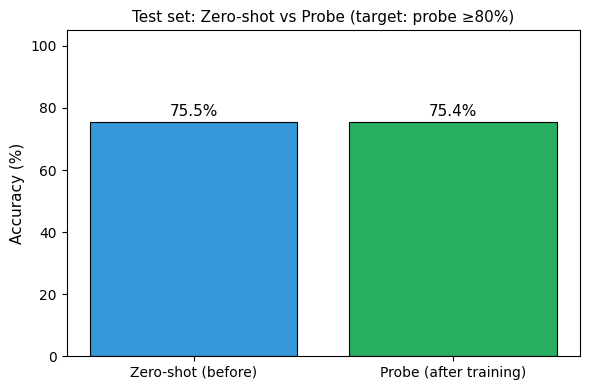

In [51]:
probe.eval()
with torch.no_grad():
    if ensemble_states is not None and len(ensemble_states) > 1:
        logits_train = torch.zeros(X_train.shape[0], 2, device=device)
        logits_test = torch.zeros(X_test.shape[0], 2, device=device)
        for state in ensemble_states:
            probe.load_state_dict({k: v.to(device) for k, v in state.items()})
            probe.eval()
            logits_train += probe(X_train)
            logits_test += probe(X_test)
        logits_train /= len(ensemble_states)
        logits_test /= len(ensemble_states)
        pred_train = logits_train.argmax(dim=1).cpu().numpy()
        pred_test = logits_test.argmax(dim=1).cpu().numpy()
    else:
        pred_train = probe(X_train).argmax(dim=1).cpu().numpy()
        pred_test = probe(X_test).argmax(dim=1).cpu().numpy()

acc_zs_train = 100 * zs_train.mean()
acc_zs_test = 100 * zs_test.mean()
acc_probe_train = 100 * (pred_train == y_train.cpu().numpy()).mean()
acc_probe_test = 100 * (pred_test == y_test.cpu().numpy()).mean()

print("Held-out test set (unseen pairs) — this is the real accuracy:")
print(f"  Zero-shot (before): {acc_zs_test:.1f}%")
print(f"  Probe (after):      {acc_probe_test:.1f}%")
print()
print("Train set (for overfitting check):")
print(f"  Zero-shot: {acc_zs_train:.1f}%  |  Probe: {acc_probe_train:.1f}%")
gap = acc_probe_train - acc_probe_test
if gap > 15:
    print(f"  -> Large train-test gap ({gap:.1f}%) suggests overfitting; consider more dropout or less capacity.")
elif acc_probe_test >= acc_zs_test:
    print(f"  -> Probe generalizes: test accuracy beats zero-shot by {acc_probe_test - acc_zs_test:.1f}%.")
else:
    print(f"  -> Probe test ({acc_probe_test:.1f}%) below zero-shot ({acc_zs_test:.1f}%); try more data or regularization.")

# Save probe test accuracy so Notebook 5 can load it for comparison
import json
Path("results/linear_probe").mkdir(parents=True, exist_ok=True)
with open("results/linear_probe/probe_test_acc.json", "w") as f:
    json.dump({"acc_probe_test": float(acc_probe_test)}, f)

# Graph: we use composite images as training data, train probe on CLIP -> accuracy on test set
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Zero-shot (before)", "Probe (after training)"]
vals = [float(acc_zs_test) if not np.isnan(acc_zs_test) else 0.0, float(acc_probe_test) if not np.isnan(acc_probe_test) else 0.0]
colors = ["#3498db", "#27ae60"]
bars = ax.bar(labels, vals, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(0, 105)
title = "Test set: probe beats zero-shot" if acc_probe_test >= acc_zs_test else "Test set: Zero-shot vs Probe (target: probe ≥80%)"
ax.set_title(title, fontsize=11)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v:.1f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

In [49]:
# Save the figure from the previous cell
try:
    fig = plt.gcf()
    out_dir = Path(CONFIG["results_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / "probe_before_after.png", dpi=150, bbox_inches="tight")
    print(f"Saved to {out_dir / 'probe_before_after.png'}")
except Exception as e:
    print(f"Run the evaluation cell above first to generate the plot. ({e})")

Saved to results/linear_probe/probe_before_after.png


<Figure size 640x480 with 0 Axes>

In [50]:
out_dir = Path(CONFIG["results_dir"])
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "probe_before_after.png", dpi=150, bbox_inches="tight")
print(f"Saved plot to {out_dir / 'probe_before_after.png'}")

Saved plot to results/linear_probe/probe_before_after.png
